# Ddri Station Clustering Baseline

이 노트북은 강남구 따릉이 대여소의 이용 패턴을 바탕으로 군집을 만드는 1차 baseline 분석 문서다.

## 이 노트북의 목적

- 2023~2025 공통 대여소 기준을 다시 확인한다.
- 전처리 기준이 어떤 로그를 남겼는지 점검한다.
- 군집화 입력 feature가 어떤 의미를 갖는지 정리한다.
- K 선택 근거와 군집 결과를 차트 중심으로 확인한다.
- 결과를 발표 자료와 레포트에서 어떻게 해석할지 연결한다.

## 입력 데이터 범위

- 학습 구간: 2023-01-01 ~ 2024-12-31
- 테스트 구간: 2025-01-01 ~ 2025-12-31
- 공간 범위: 강남구 따릉이 대여소
- 기준 대여소: 2023~2025 공통 대여소 169개

## 이 노트북에서 직접 확인할 산출물

- 공통 대여소 마스터
- 전처리 로그와 coverage 요약
- 군집화 feature 테이블
- K 탐색 결과
- PCA / feature 비교 / heatmap / 추이 차트

## 해석 시 주의점

- 이 노트북은 `기존 운영 대여소` 중심의 군집화 baseline이다.
- 신규 대여소는 cold-start 문제로 분리해 다루며, 이 노트북의 메인 평가 범위에 포함하지 않는다.
- 군집은 `원인 확정`이 아니라 `패턴 구조화` 단계이므로, 환경/POI 해석은 후속 근거와 함께 보강한다.

## 1. 기본 설정과 경로 확인

먼저 현재 구조에서 사용하는 원본 데이터 경로와 생성 산출물 경로를 고정한다. 이 셀은 이후 모든 표와 차트가 어디서 읽히는지 추적하기 위한 시작점이다.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

BASE_DIR = Path('/Users/cheng80/Desktop/ddri_work')
RAW_DIR = BASE_DIR / '3조 공유폴더'
CLUSTER_DATA_DIR = BASE_DIR / 'works' / '01_clustering' / '06_data'
PREP_DATA_DIR = BASE_DIR / 'works' / '01_clustering' / '02_preprocessing' / 'data'
CLUSTER_IMG_DIR = BASE_DIR / 'works' / '01_clustering' / '07_images'
ENV_DATA_DIR = BASE_DIR / 'works' / '01_clustering' / '03_environment' / 'data'
ENV_IMG_DIR = BASE_DIR / 'works' / '01_clustering' / '03_environment' / 'images'

print('raw exists:', RAW_DIR.exists())
print('cluster data dir:', CLUSTER_DATA_DIR)
print('cluster image dir:', CLUSTER_IMG_DIR)

raw exists: True
cluster data dir: /Users/cheng80/Desktop/ddri_work/works/01_clustering/06_data
cluster image dir: /Users/cheng80/Desktop/ddri_work/works/01_clustering/07_images


## 2. 공통 대여소 기준 확인

군집화의 시작점은 연도별 대여소 집합을 동일하게 맞추는 것이다. 이 프로젝트에서는 2023~2025 모두에 존재하는 대여소만 남겨 비교 가능한 baseline을 구성했다.

In [2]:
station_year_summary = pd.read_csv(CLUSTER_DATA_DIR / 'ddri_station_master_year_summary.csv')
coverage_summary = pd.read_csv(CLUSTER_DATA_DIR / 'ddri_station_coverage_summary.csv')
common_master = pd.read_csv(CLUSTER_DATA_DIR / 'ddri_common_station_master.csv')

print('연도별 대여소 수')
display(station_year_summary)
print('공통 마스터 개수:', len(common_master))
print('coverage 요약')
display(coverage_summary)

연도별 대여소 수


,year,station_count,only_this_year_count
0,2023,175,4
1,2024,176,1
2,2025,179,6
3,common_2023_2024_2025,169,0


공통 마스터 개수: 169
coverage 요약


,group,station_count
0,common_station_master,169
1,train_feature_station_count,164
2,test_feature_station_count,162
3,missing_in_train,5
4,missing_in_test,7
5,missing_in_both,4


## 3. 전처리 기준과 로그 확인

군집화 결과의 신뢰도는 전처리 기준에 크게 좌우된다. 여기서는 결측치, 0 이하 시간/거리, 기준 밖 대여소, 강남구 밖 반납 등 제거 기준이 실제로 어떻게 집계되었는지 확인한다.

같은 대여소로 반납된 이동(self-return)은 이상치로 제거하지 않는다. 실제 이용은 발생했기 때문에 수요는 유지하고, 대신 이후 운영 해석에서 별도 지표로 관리한다.

In [3]:
cleaning_summary = pd.read_csv(PREP_DATA_DIR / 'ddri_cleaning_summary_by_group.csv')
duplicate_summary = pd.read_csv(PREP_DATA_DIR / 'ddri_duplicate_check_summary.csv')
outlier_summary = pd.read_csv(PREP_DATA_DIR / 'ddri_feature_iqr_outlier_summary.csv')

print('전처리 그룹별 요약')
display(cleaning_summary)
print('중복 로그 요약')
display(duplicate_summary)
print('IQR 기준 극단치 후보 요약')
display(outlier_summary)

전처리 그룹별 요약


,group_name,rows_before,rows_after,dropped_missing,dropped_nonpositive,dropped_noncommon_rent,dropped_outside_gangnam_return
0,test_2025,869397,825111,0,15022,29264,0
1,train_2023,1012480,917202,0,68978,26300,0
2,train_2024,1014918,943381,0,54057,17480,0


중복 로그 요약


,files,rows,dup_all,dup_key
0,36,2896795,21,21


IQR 기준 극단치 후보 요약


,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count
0,avg_rental,8.656448,19.009784,10.353336,-6.873557,34.539788,12
1,rental_std,5.547695,11.063102,5.515407,-2.725415,19.336213,6
2,weekday_avg,9.433483,20.984080,11.550597,-7.892412,38.309975,11
3,weekend_avg,6.867890,15.705529,8.837638,-6.388567,28.961986,13
4,peak_ratio,0.338877,0.403111,0.064234,0.242525,0.499463,6
5,night_ratio,0.109443,0.156774,0.047330,0.038448,0.227769,6
6,weekday_weekend_gap,0.913976,6.099563,5.185587,-6.864404,13.877943,11


## 4. 군집화 feature 구조 확인

군집은 대여소별 일 단위 집계를 바탕으로 만든 feature를 입력으로 사용한다. 각 변수는 다음 의미를 가진다.

- `avg_rental`: 평균 대여량
- `rental_std`: 대여량 변동성
- `weekday_avg`, `weekend_avg`: 평일/주말 평균 대여량
- `peak_ratio`: 출퇴근 시간대 비중
- `night_ratio`: 야간 대여 비중
- `weekday_weekend_gap`: 평일과 주말 차이

즉 군집은 단순 위치 분류가 아니라, 대여소별 수요 패턴을 구조화한 결과다.

In [4]:
train_features = pd.read_csv(CLUSTER_DATA_DIR / 'ddri_station_cluster_features_train_2023_2024.csv')
test_features = pd.read_csv(CLUSTER_DATA_DIR / 'ddri_station_cluster_features_test_2025.csv')
train_labeled = pd.read_csv(CLUSTER_DATA_DIR / 'ddri_station_cluster_features_train_with_labels.csv')

print('학습 feature shape:', train_features.shape)
print('테스트 feature shape:', test_features.shape)
display(train_labeled.head())

학습 feature shape: (164, 8)
테스트 feature shape: (162, 8)


,station_id,avg_rental,rental_std,weekday_avg,weekend_avg,peak_ratio,night_ratio,weekday_weekend_gap,cluster,pca_1,pca_2
0,2301,23.529903,19.177993,20.294922,31.531401,0.354061,0.164026,-11.236479,1,1.689282,2.581985
1,2302,19.291549,9.695116,20.570866,16.074257,0.338906,0.221800,4.496609,0,0.415562,1.941239
2,2303,24.606019,12.696377,26.948276,18.755981,0.394118,0.158225,8.192295,1,1.852584,0.295885
3,2304,8.493488,6.244850,9.156627,6.782383,0.410291,0.128642,2.374243,0,-1.386551,-0.637807
4,2305,7.186317,4.167441,8.421569,3.627119,0.408750,0.072919,4.794450,0,-1.650573,-1.822125


## 5. K 선택 근거 확인

KMeans는 군집 수를 사전에 정해야 하므로, Elbow와 Silhouette를 함께 본다. 이 프로젝트의 1차 baseline에서는 설명 가능성과 분리도를 같이 고려해 silhouette가 가장 좋은 `k=2`를 우선 채택했다.

In [5]:
k_search = pd.read_csv(CLUSTER_DATA_DIR / 'ddri_kmeans_search_metrics.csv')
display(k_search)
best_row = k_search.sort_values(['silhouette', 'k'], ascending=[False, True]).iloc[0]
print('선택된 k:', int(best_row['k']))
print('최고 silhouette:', round(float(best_row['silhouette']), 3))

,k,inertia,silhouette
0,2,698.003718,0.438880
1,3,556.630740,0.275776
2,4,449.943387,0.292718
3,5,385.463609,0.285309
4,6,328.866589,0.281579


선택된 k: 2
최고 silhouette: 0.439


## 6. 근거 차트 확인

아래 차트들은 단순 결과 소개용이 아니라, 왜 이 구조를 선택했는지 설명하기 위한 근거 차트다.

- Elbow / Silhouette: K 선택 근거
- PCA 산점도: 군집 분리도 확인
- 군집별 특성 평균: 각 군집의 패턴 차이 확인
- 상관관계 heatmap: feature 간 중복/연관 구조 확인
- 군집 프로파일 heatmap: 군집별 특성 강약 비교
- 군집별 대여소 수: 결과 불균형 확인
- 월별 추이 / 요일-시간 heatmap: 전체 수요 패턴 배경 확인

ddri_kmeans_elbow_silhouette.png exists= True


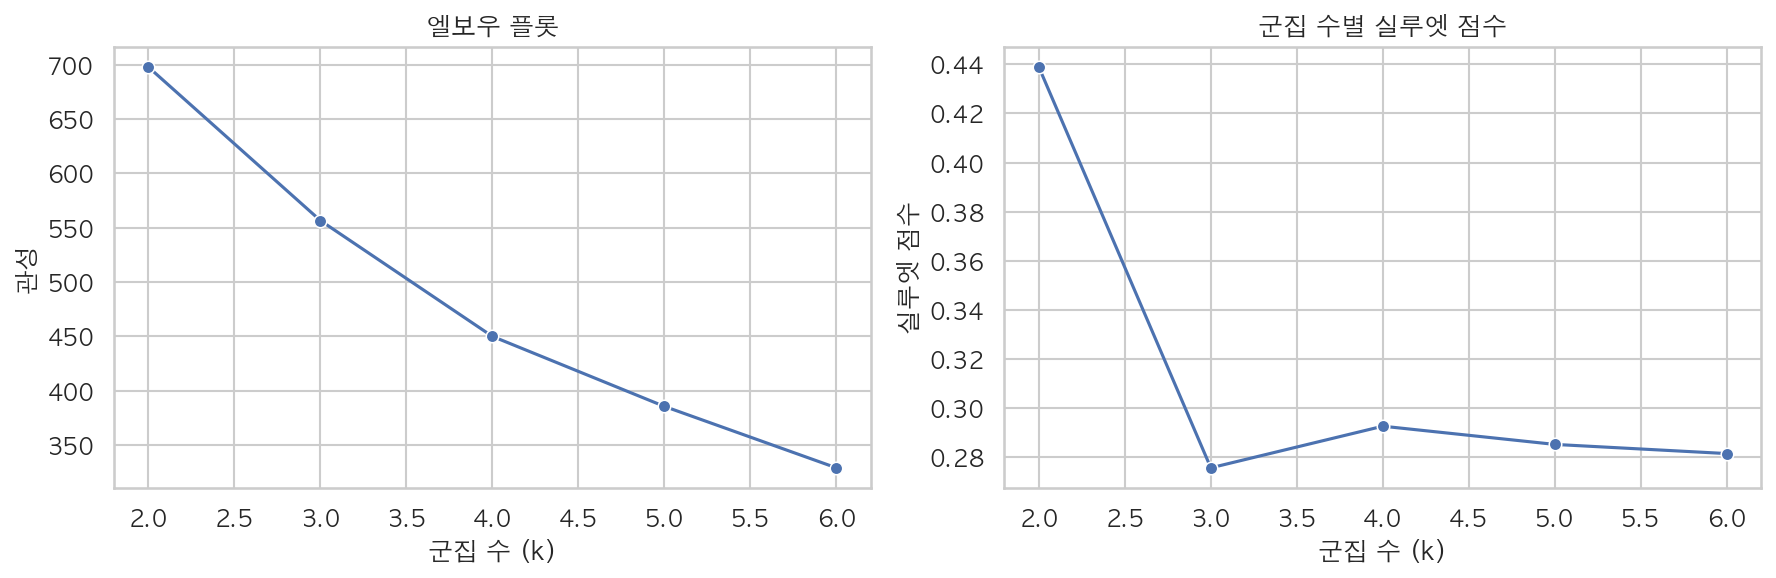

ddri_kmeans_pca_scatter.png exists= True


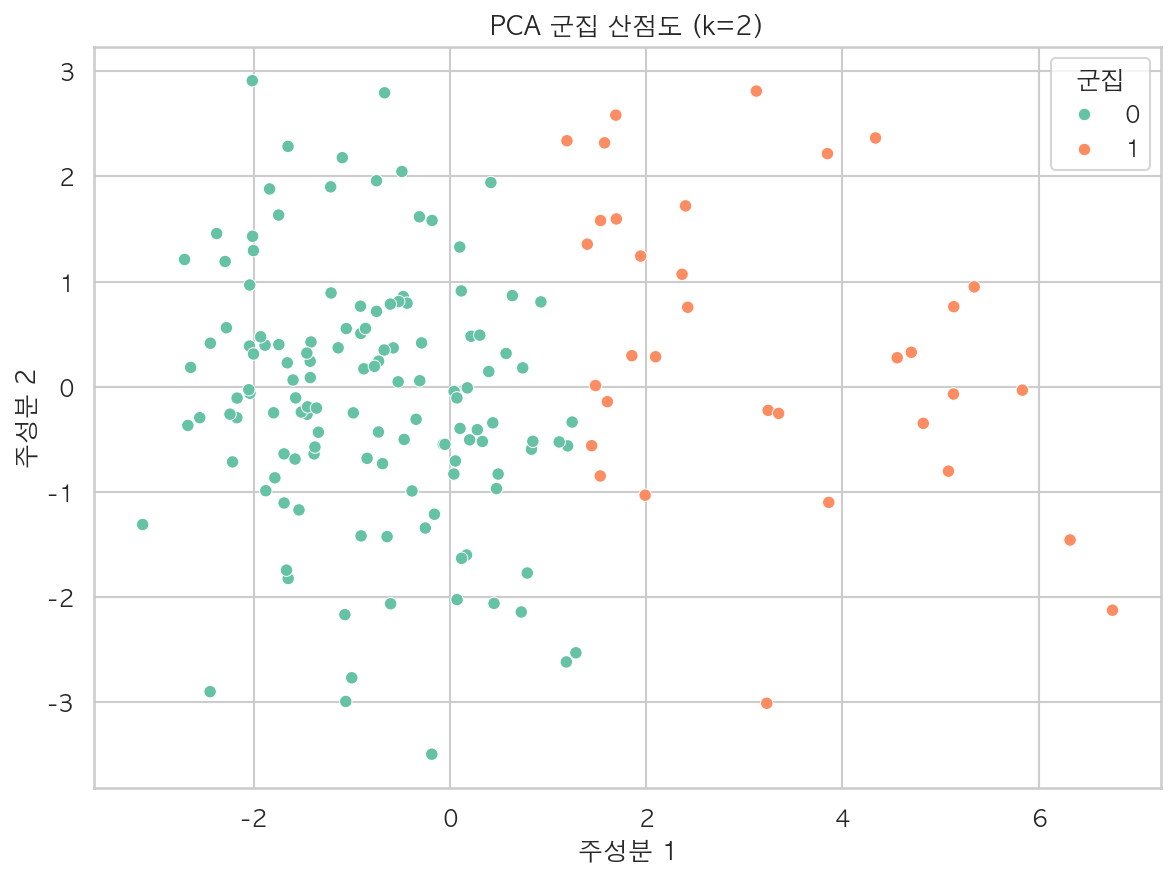

ddri_cluster_feature_means.png exists= True


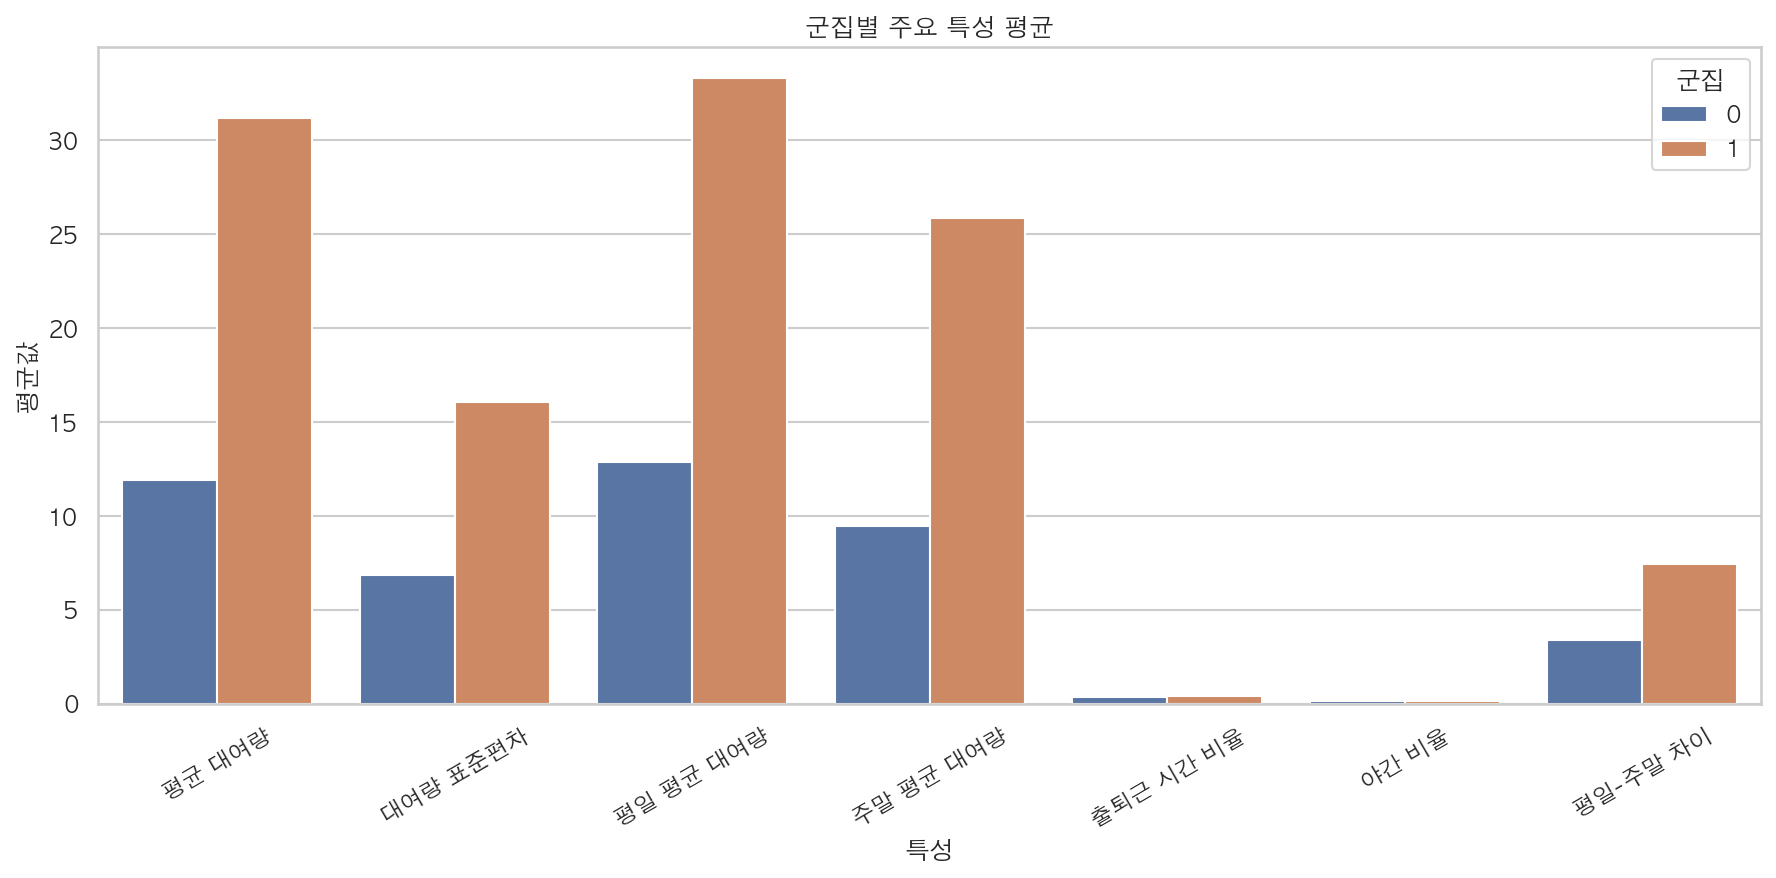

ddri_feature_correlation_heatmap.png exists= True


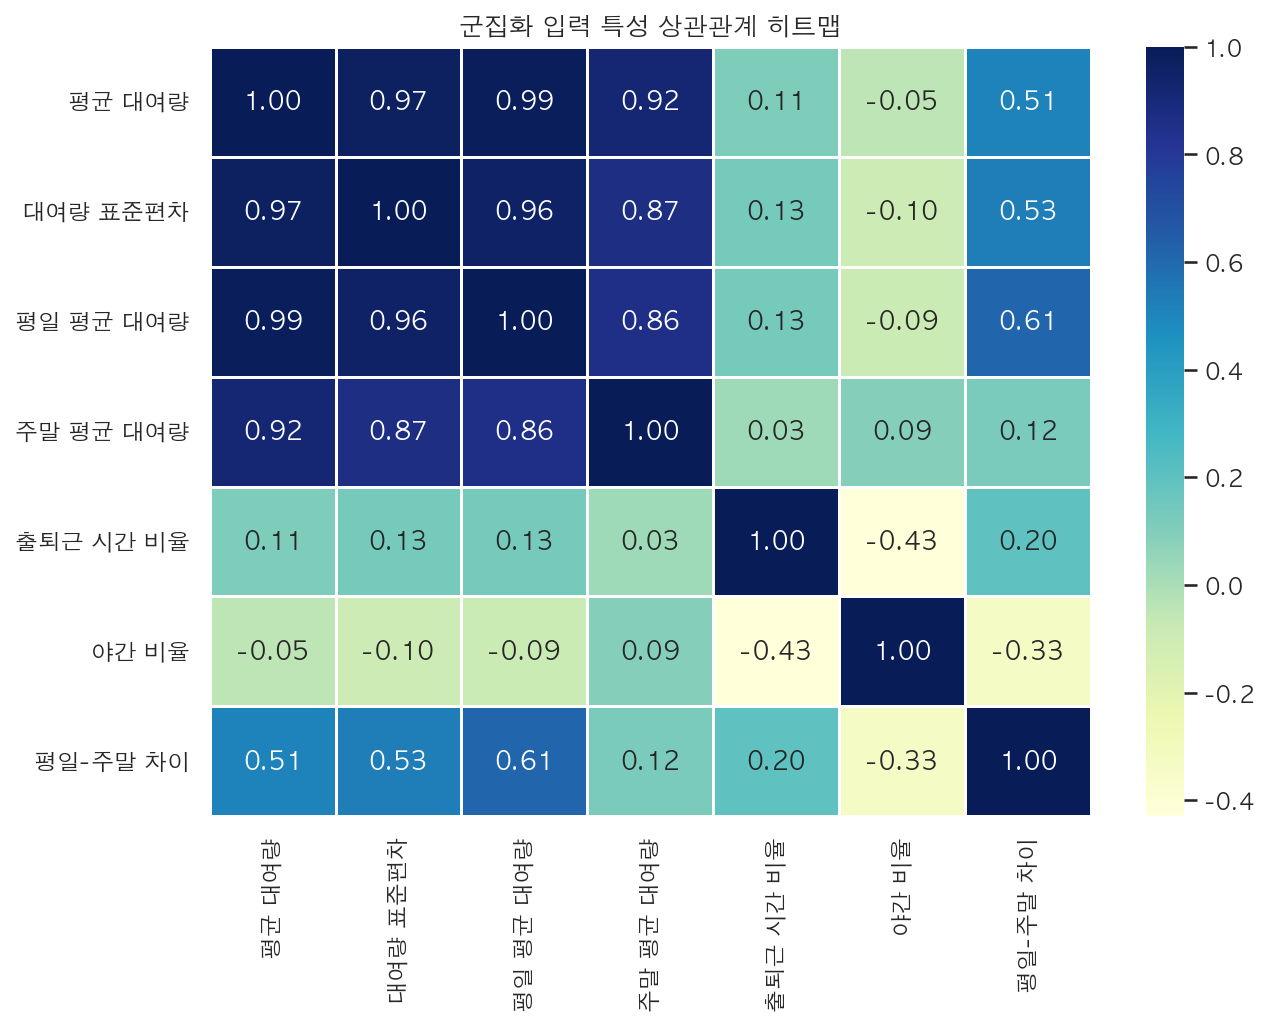

ddri_cluster_profile_heatmap.png exists= True


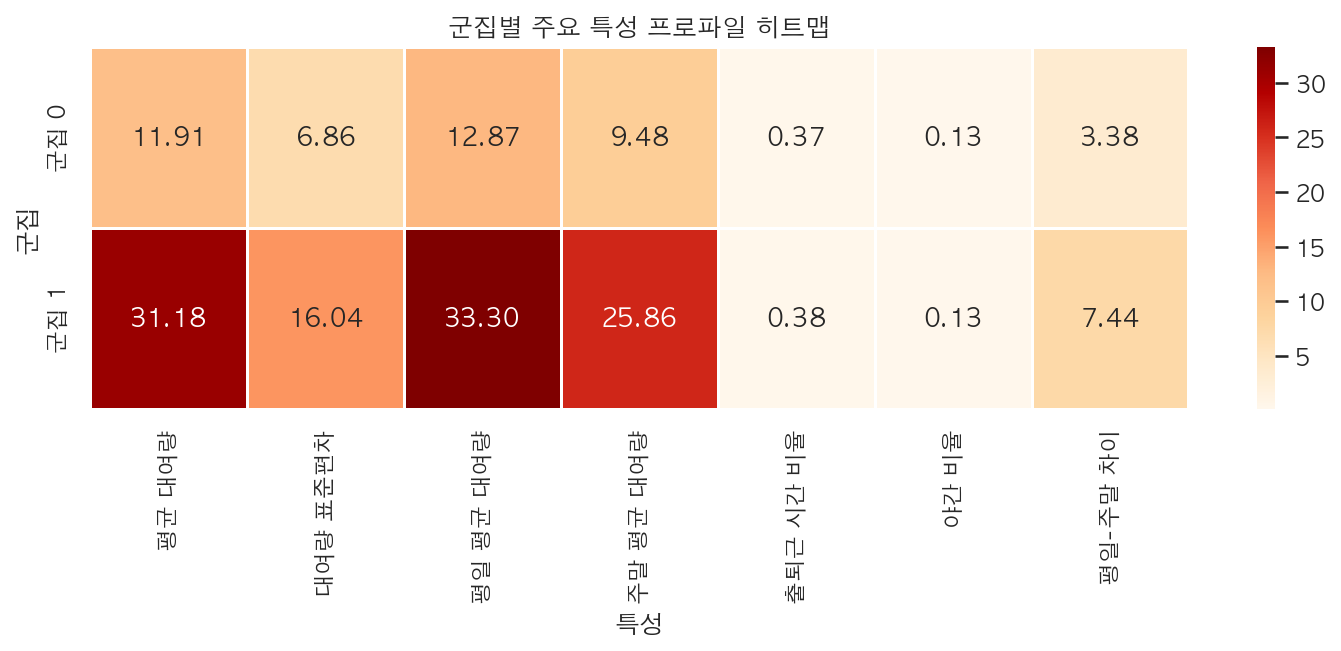

ddri_cluster_size.png exists= True


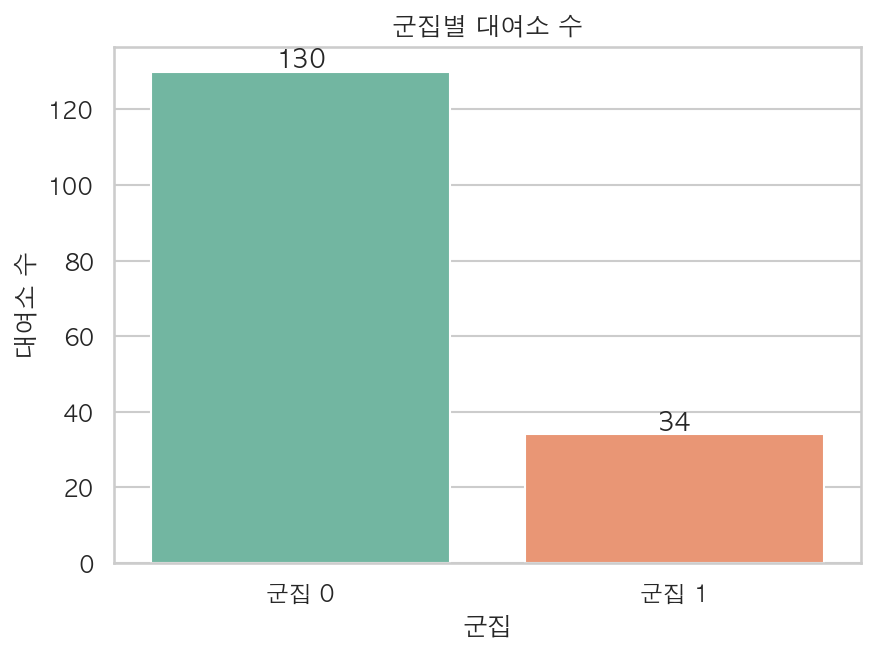

ddri_monthly_rental_trend.png exists= True


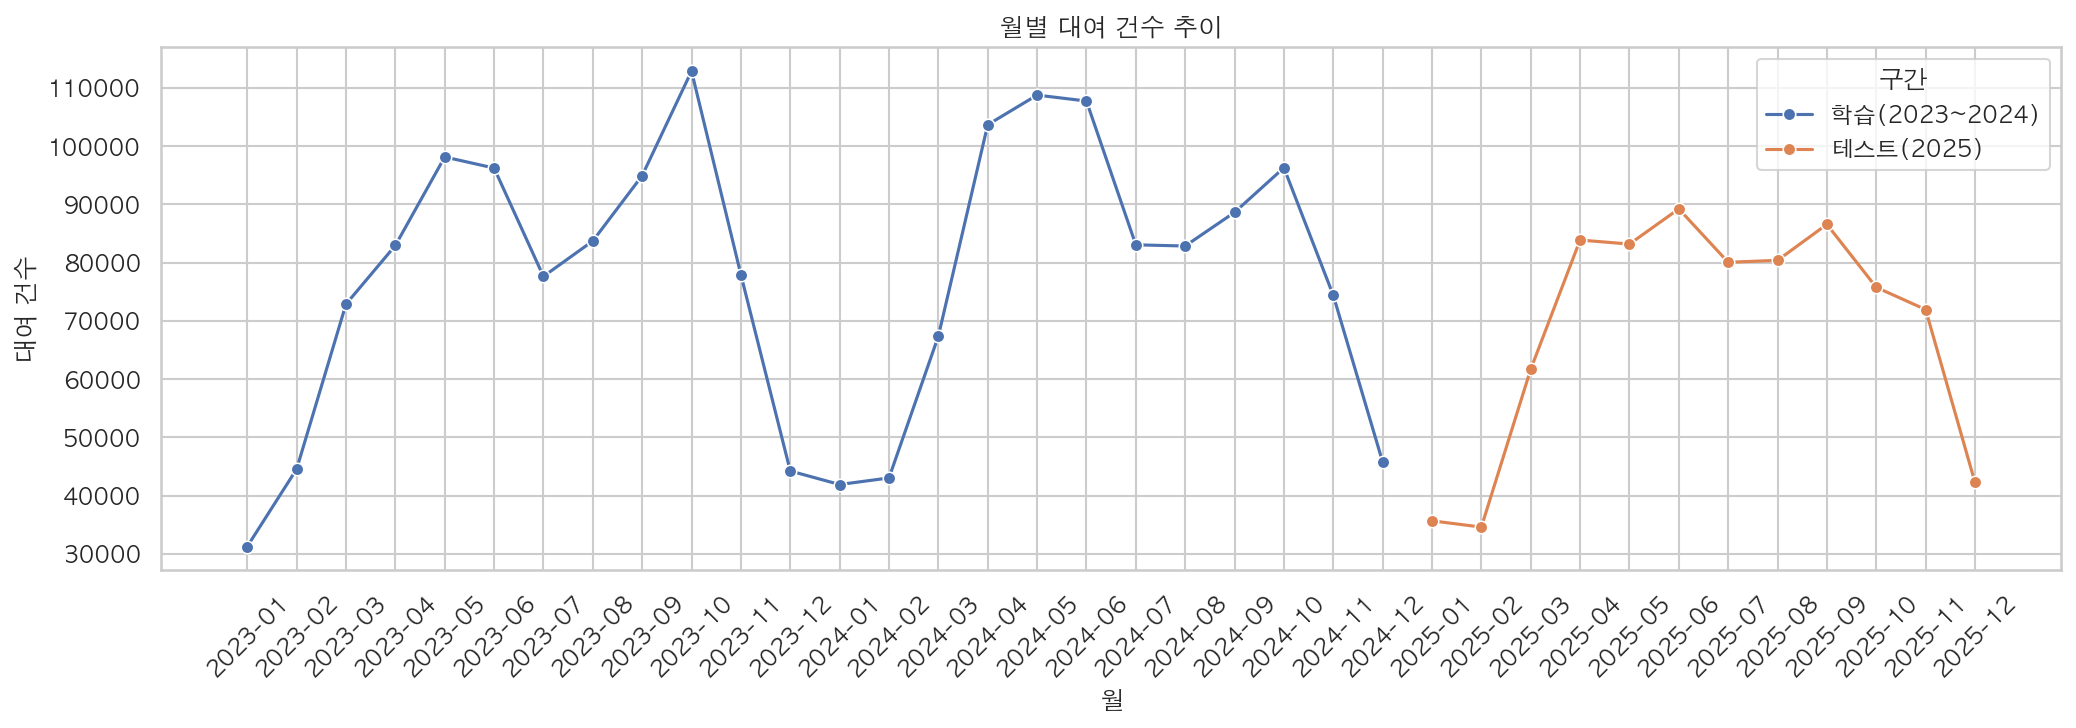

ddri_weekday_hour_heatmap.png exists= True


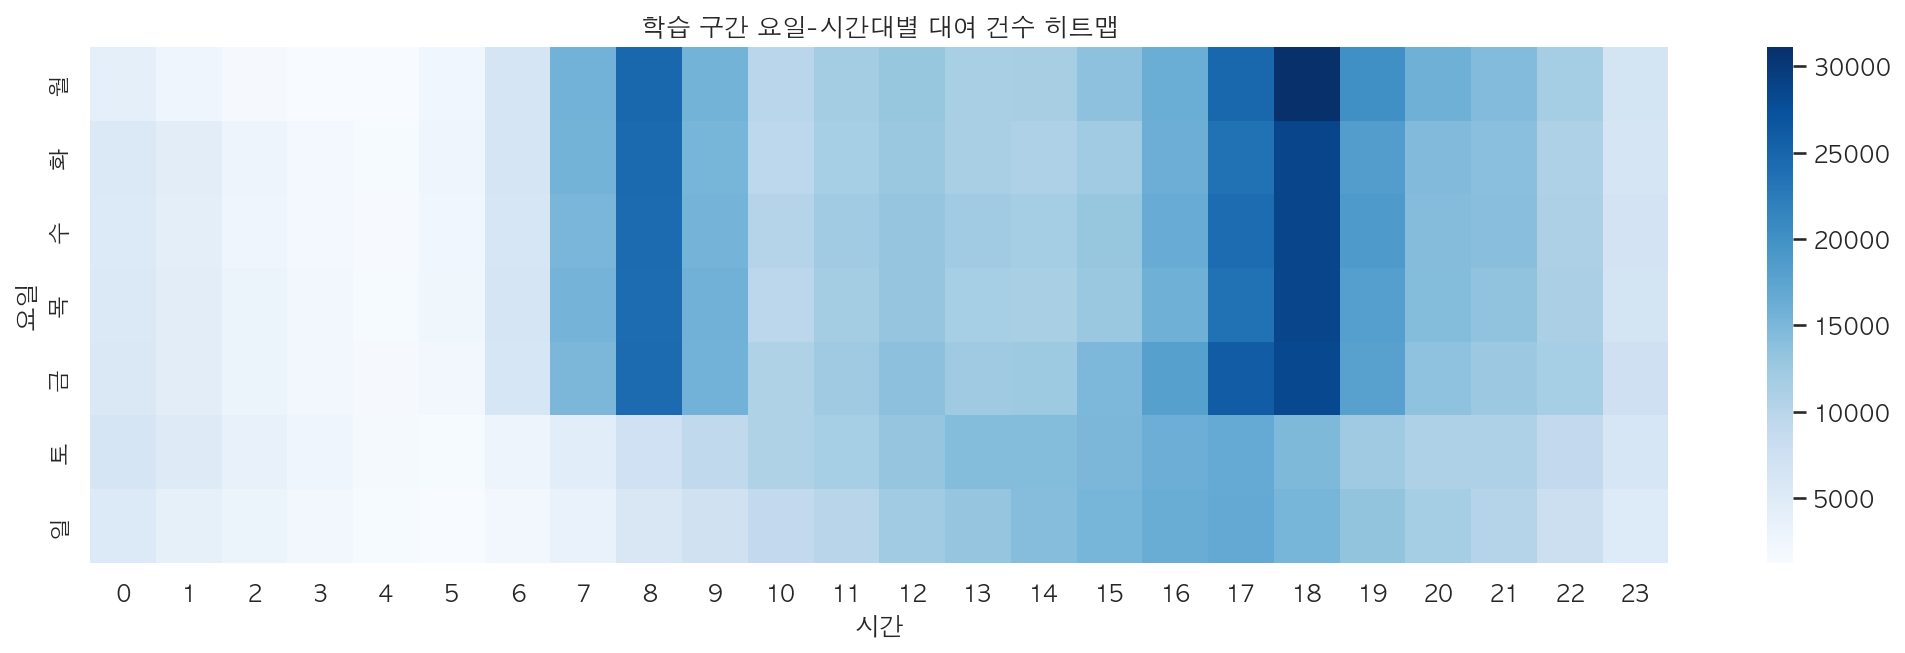

In [6]:
for image_name in [
    'ddri_kmeans_elbow_silhouette.png',
    'ddri_kmeans_pca_scatter.png',
    'ddri_cluster_feature_means.png',
    'ddri_feature_correlation_heatmap.png',
    'ddri_cluster_profile_heatmap.png',
    'ddri_cluster_size.png',
    'ddri_monthly_rental_trend.png',
    'ddri_weekday_hour_heatmap.png',
]:
    image_path = CLUSTER_IMG_DIR / image_name
    print(image_name, 'exists=', image_path.exists())
    if image_path.exists():
        display(Image(filename=image_path))

## 7. 군집 요약 해석

군집별 평균을 보면 이번 1차 결과는 `일반수요형`과 `고수요형` 구분이 가장 핵심적이다. 현재 단계에서는 `출퇴근형`이나 `상업지구형`으로 단정하지 않고, 수요 규모와 교통 접근성 차이를 확인하는 수준에서 해석하는 것이 안전하다.

In [7]:
cluster_summary = pd.read_csv(CLUSTER_DATA_DIR / 'ddri_cluster_summary.csv', index_col=0)
environment_summary = pd.read_csv(ENV_DATA_DIR / 'ddri_cluster_environment_summary.csv')
representative = pd.read_csv(ENV_DATA_DIR / 'ddri_cluster_representative_stations.csv')

print('군집별 주요 특성 평균')
display(cluster_summary)
print('군집별 환경 요약')
display(environment_summary)
print('대표 대여소 샘플')
display(representative.head(10))

군집별 주요 특성 평균


,avg_rental,rental_std,weekday_avg,weekend_avg,peak_ratio,night_ratio,weekday_weekend_gap
cluster,,,,,,,
0,11.913,6.856,12.865,9.479,0.373,0.133,3.385
1,31.176,16.039,33.300,25.860,0.382,0.134,7.440


군집별 환경 요약


,cluster,cluster_name,park_distance_m,subway_distance_m,bus_stop_count_300m,bus_stop_count_500m,avg_rental
0,0,일반수요형,1036.82,551.64,26.98,60.48,11.91
1,1,고수요형,1170.43,387.75,32.56,68.09,31.18


대표 대여소 샘플


,station_id,avg_rental,rental_std,weekday_avg,weekend_avg,peak_ratio,night_ratio,weekday_weekend_gap,cluster,pca_1,...,주소,station_lat,station_lon,park_distance_m,nearest_park_name,subway_distance_m,nearest_subway_name,bus_stop_count_300m,bus_stop_count_500m,cluster_name
0,2308,21.877915,9.994926,22.692898,19.836538,0.320083,0.121951,2.856360,0,0.925599,...,서울특별시 강남구 압구정로 311,37.529301,127.035599,516.774113,도산근린공원,484.737255,압구정로데오,20,56,일반수요형
1,4914,21.546703,11.140371,24.130518,15.043478,0.309065,0.079051,9.087040,0,1.244237,...,삼성동 159-9,37.509991,127.058472,508.029365,봉은공원,432.747544,삼성(무역센터),28,132,일반수요형
2,2324,20.709589,9.378962,20.908046,20.211538,0.341447,0.131036,0.696508,0,0.634741,...,서울특별시 강남구 도곡로 540,37.500439,127.066223,1771.069315,봉은공원,570.038639,학여울,32,48,일반수요형
3,4923,20.486676,9.486546,21.212181,18.676471,0.373451,0.119806,2.535710,0,0.740561,...,서울특별시 강남구 영동대로 214-2,37.498615,127.068314,2041.540219,봉은공원,295.966488,학여울,12,64,일반수요형
4,4902,20.112329,11.051742,23.442529,11.754808,0.356559,0.116810,11.687721,0,1.112515,...,강남구 논현로 337,37.495243,127.039375,741.472593,도곡근린공원,651.200311,역삼,20,60,일반수요형
5,2349,19.642061,12.490611,22.694391,11.791045,0.401617,0.139616,10.903346,0,1.198205,...,서울특별시 강남구 테헤란로 지하 156,37.501545,127.038567,1373.116615,도곡근린공원,212.598093,역삼,20,60,일반수요형
6,2302,19.291549,9.695116,20.570866,16.074257,0.338906,0.221800,4.496609,0,0.415562,...,서울특별시 강남구 봉은사로 지하 102,37.505581,127.024277,2325.377527,도산근린공원,129.301580,신논현,40,124,일반수요형
7,2410,18.915862,10.224407,22.115607,10.854369,0.349278,0.109450,11.261238,0,0.829468,...,강남구 역삼동 804(강남구 테헤란로 134 앞 보도),37.499599,127.033752,1434.195188,도곡근린공원,264.215562,역삼,16,64,일반수요형
8,3604,18.761317,11.850863,22.285441,9.874396,0.491409,0.086276,12.411044,0,1.282427,...,삼성동145-1,37.512962,127.053864,177.948049,봉은공원,51.576429,삼성중앙,16,48,일반수요형
9,2333,18.691034,11.338391,21.739884,11.009709,0.483285,0.066637,10.730176,0,1.185033,...,서울특별시 강남구 강남대로 240,37.485157,127.034073,1124.248084,도곡근린공원,77.102262,양재(서초구청),52,120,일반수요형


## 8. 이 노트북의 결론

- 군집화 baseline은 재현 가능한 형태로 고정되었다.
- `k=2`는 현재 기준에서 가장 안정적인 1차 구조다.
- 군집은 수요 규모 차이와 교통 접근성 차이를 함께 보인다.
- 이후 단계에서는 POI, 예측용 feature, 운영 지표를 결합해 해석력과 예측력을 확장한다.